# Kemuel Marvila 21.1.4013

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from prefixspan import PrefixSpan
from sklearn.feature_selection import mutual_info_regression

In [2]:
# Carregar os dados
data_dir = "../house-prices-data/"
try:
    # Tente carregar do seu ambiente local
    train_df = pd.read_csv(data_dir + 'train.csv')
    test_df = pd.read_csv(data_dir + 'test.csv')
except FileNotFoundError:
    print("Arquivos 'train.csv' e 'test.csv' não encontrados. Certifique-se de que estão no diretório correto.")
# Visualizar as primeiras linhas do conjunto de treino
if not train_df.empty:
    print("Amostra do Conjunto de Treino:")
    display(train_df.head())

df = train_df.copy()

Amostra do Conjunto de Treino:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
def impute_house_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Corrige valores ausentes nas colunas críticas do conjunto Ames House Prices.

    Estratégias aplicadas
    ---------------------
    • **BsmtQual**      : 'NA'  (descrição já prevê esse rótulo = *No Basement*)  
    • **GarageType**    : 'NA'  (descrição já prevê esse rótulo = *No Garage*)  
    • **FireplaceQu**   : 'NA'  (descrição já prevê esse rótulo = *No Fireplace*)  
    • **GarageYrBlt**   :  
        └── Se a casa **possui garagem** → usa `YearBuilt` (garagem geralmente construída junto)  
        └── Se **não possui garagem**   → preenche 0 (código neutro)  
    • **LotFrontage**   : mediana do bairro (`Neighborhood`) — mantém coerência espacial.

    Retorna
    -------
    DataFrame novo, sem modificar o original.
    """
    df = df.copy()

    # 1) Categóricos cujo próprio dicionário prevê o rótulo "NA"
    na_label_cols = ["BsmtQual", "GarageType", "FireplaceQu"]
    for col in na_label_cols:
        df[col] = df[col].fillna("NA")

    # 2) GarageYrBlt — depende se há garagem ou não
    mask_no_garage = df["GarageType"] == "NA"
    # a) casas SEM garagem → 0
    df.loc[mask_no_garage, "GarageYrBlt"] = df.loc[mask_no_garage, "GarageYrBlt"].fillna(0)
    # b) casas COM garagem → assume que a garagem foi construída no mesmo ano da casa
    df.loc[~mask_no_garage, "GarageYrBlt"] = df.loc[~mask_no_garage, "GarageYrBlt"].fillna(
        df.loc[~mask_no_garage, "YearBuilt"]
    )

    # 3) LotFrontage — mediana por Neighborhood para preservar contexto
    lotfront_median_by_nbhd = (
        df.groupby("Neighborhood")["LotFrontage"]
        .transform("median")
    )
    df["LotFrontage"] = df["LotFrontage"].fillna(lotfront_median_by_nbhd)

    return df


df_fixed = impute_house_prices(df)
df_fixed.isna().sum()[df_fixed.isna().sum() > 0]

df = df_fixed.copy()

Iniciando cálculo de Informação Mútua...

--- Top 30 Atributos Mais Relevantes por Informação Mútua ---
OverallQual     0.564319
Neighborhood    0.502301
GrLivArea       0.482313
GarageCars      0.368256
TotalBsmtSF     0.366934
YearBuilt       0.366387
GarageArea      0.366115
BsmtQual        0.329119
KitchenQual     0.318267
1stFlrSF        0.309579
ExterQual       0.306704
MSSubClass      0.279689
FullBath        0.271870
GarageFinish    0.261872
GarageYrBlt     0.259899
YearRemodAdd    0.252671
LotFrontage     0.223301
TotRmsAbvGrd    0.214940
GarageType      0.209591
2ndFlrSF        0.205615
FireplaceQu     0.205548
Foundation      0.191581
HeatingQC       0.168878
Exterior2nd     0.165029
Fireplaces      0.164154
LotArea         0.159205
BsmtFinType1    0.151218
BsmtFinSF1      0.148321
OpenPorchSF     0.145932
Exterior1st     0.130290


/tmp/ipykernel_2833/2937362155.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mi.values, y=top_mi.index, palette="viridis")


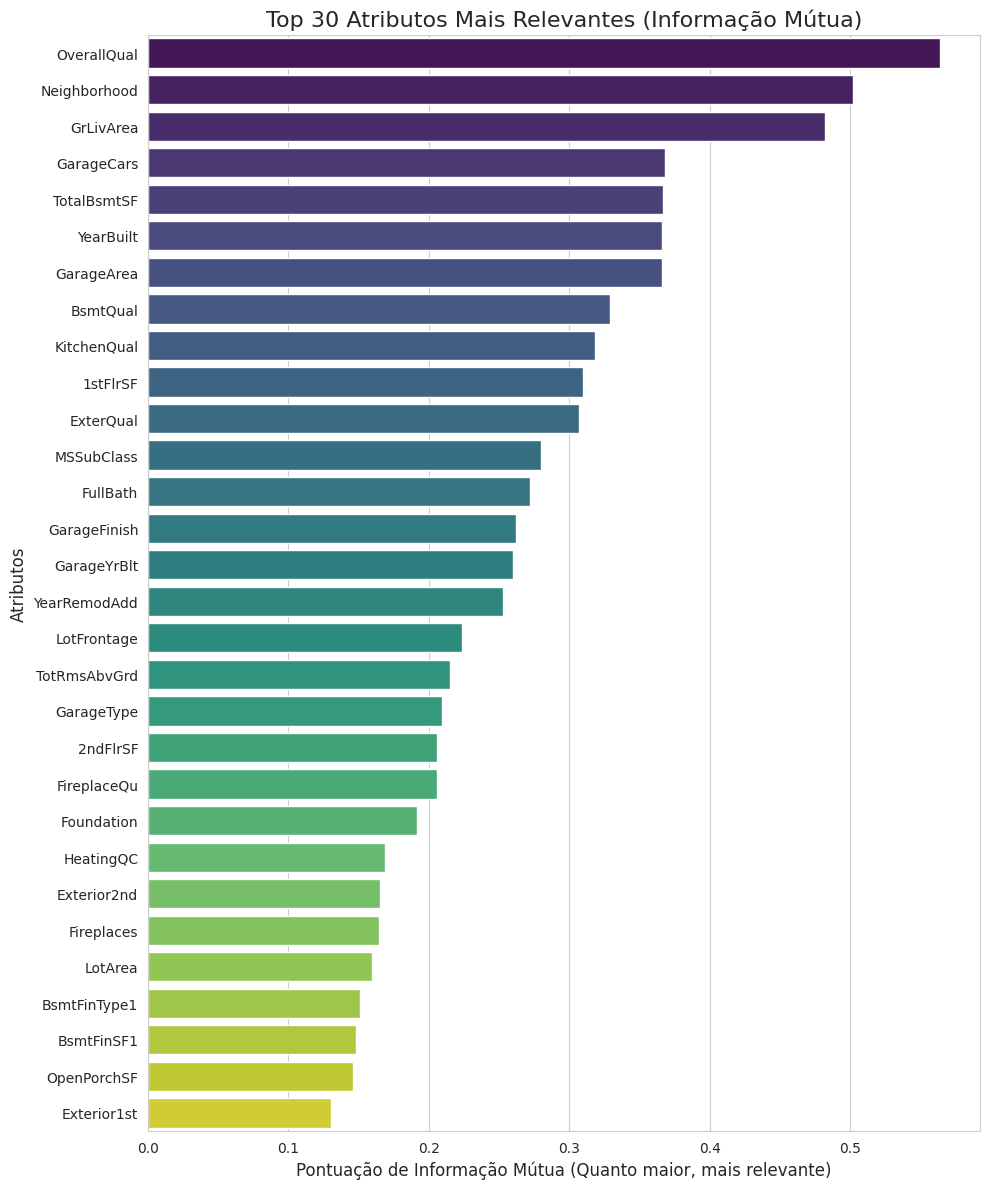

In [4]:
def plotar_informacao_mutua(df):
    """
    Calcula e plota a Informação Mútua entre os atributos de um dataframe e a coluna 'SalePrice'.

    Args:
        df (pd.DataFrame): O dataframe de treino contendo os atributos e a coluna 'SalePrice'.
    """
    print("Iniciando cálculo de Informação Mútua...")

    # 1. Preparar os dados
    df_mi = df.copy()
    if 'Id' in df_mi.columns:
        df_mi = df_mi.drop('Id', axis=1)

    # Tratar valores ausentes (NaN) antes do encoding
    # Para colunas numéricas, usamos a mediana
    for col in df_mi.select_dtypes(include=np.number):
        if df_mi[col].isnull().any():
            df_mi[col] = df_mi[col].fillna(df_mi[col].median())
            
    # Para colunas de texto (categóricas), usamos um valor placeholder
    for col in df_mi.select_dtypes("object"):
        if df_mi[col].isnull().any():
            df_mi[col] = df_mi[col].fillna("missing")

    # Converter colunas categóricas para um formato numérico que a função entende
    for col in df_mi.select_dtypes("object"):
        df_mi[col], _ = pd.factorize(df_mi[col])

    # 2. Separar features (X) e alvo (y)
    X = df_mi.drop('SalePrice', axis=1)
    y = df_mi['SalePrice']

    # 3. Calcular Informação Mútua
    # O random_state garante que o resultado seja o mesmo toda vez que rodar
    mi_scores = mutual_info_regression(X, y, random_state=0)
    mi_scores = pd.Series(mi_scores, name="Pontuação MI", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    # 4. Exibir os resultados
    print("\n--- Top 30 Atributos Mais Relevantes por Informação Mútua ---")
    print(mi_scores.head(30).to_string())

    # Plotar os 30 atributos mais relevantes
    plt.figure(figsize=(10, 12))
    top_mi = mi_scores.head(30)
    sns.set_style("whitegrid")
    sns.barplot(x=top_mi.values, y=top_mi.index, palette="viridis")
    plt.title('Top 30 Atributos Mais Relevantes (Informação Mútua)', fontsize=16)
    plt.xlabel('Pontuação de Informação Mútua (Quanto maior, mais relevante)', fontsize=12)
    plt.ylabel('Atributos', fontsize=12)
    plt.tight_layout()
    plt.show()


# --- Como usar a função no seu notebook ---
# Certifique-se de que seu dataframe 'train_df' está carregado
# train_df = pd.read_csv('../house-prices-data/train.csv') 

# Em seguida, simplesmente chame a função:
plotar_informacao_mutua(df)

In [5]:
corr_cols = [
    "OverallQual",
    "Neighborhood",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "BsmtQual",
    "KitchenQual",
    "1stFlrSF",
    "ExterQual",
    "GarageYrBlt",
    "MSSubClass",
    "FullBath",
    "YearRemodAdd",
    "LotFrontage",
    "TotRmsAbvGrd",
    "GarageType",
    "2ndFlrSF",
    "FireplaceQu"
]
BIN_LABELS = ["M_B", "B", "M", "A", "M_A"]  # Muito Baixo, Baixo, Medio, Alto, Muito Alto.

target_col = "SalePrice"
df_rel = df[corr_cols + [target_col]].copy()
print(f"Tamanho do conjunto selecionado: {df_rel.shape}")
display(df_rel.head())

Tamanho do conjunto selecionado: (1460, 20)


,OverallQual,Neighborhood,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,BsmtQual,KitchenQual,1stFlrSF,ExterQual,GarageYrBlt,MSSubClass,FullBath,YearRemodAdd,LotFrontage,TotRmsAbvGrd,GarageType,2ndFlrSF,FireplaceQu,SalePrice
0,7,CollgCr,1710,2,856,2003,Gd,Gd,856,Gd,2003.0,60,2,2003,65.0,8,Attchd,854,NA,208500
1,6,Veenker,1262,2,1262,1976,Gd,TA,1262,TA,1976.0,20,2,1976,80.0,6,Attchd,0,TA,181500
2,7,CollgCr,1786,2,920,2001,Gd,Gd,920,Gd,2001.0,60,2,2002,68.0,6,Attchd,866,TA,223500
3,7,Crawfor,1717,3,756,1915,TA,Gd,961,TA,1998.0,70,1,1970,60.0,7,Detchd,756,Gd,140000
4,8,NoRidge,2198,3,1145,2000,Gd,Gd,1145,Gd,2000.0,60,2,2000,84.0,9,Attchd,1053,TA,250000


In [6]:
df_rel.isna().sum()[df_rel.isna().sum() > 0]

Series([], dtype: int64)

qcut é ideal aqui porque divide com base na distribuição dos dados, e não em faixas de valor fixo.
cut sempre cria faixas com larguras iguais (divisão em 5 partes uniformes no eixo dos valores). Isso garante que todos os atributos, mesmo com poucos valores distintos, sejam discretizados

In [7]:
def discretize_numeric(df: pd.DataFrame, target: str = "SalePrice") -> pd.DataFrame:
    """
    Discretiza todos os atributos numéricos (exceto o alvo) em 5 quintis.
    Usa `qcut`; se falhar por falta de quantis únicos, cai para `cut`.

    Mantém atributos não‑numéricos (ou já discretizados) intocados.
    """
    df = df.copy()
    # Discretiza o alvo
    df[f"{target}Bin"] = pd.qcut(
        df[target], q=5, labels=BIN_LABELS, duplicates="drop"
    )

    numeric_cols = df.select_dtypes(include=["int", "float"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target]  # exclui o alvo bruto

    for col in numeric_cols:
        try:
            df[col] = pd.qcut(df[col], q=5, labels=BIN_LABELS, duplicates="drop")
        except ValueError:
            # Fallback para cut com faixas iguais
            df[col] = pd.cut(
                df[col],
                bins=5,
                labels=BIN_LABELS,
                include_lowest=True,
                right=True,
            )

    return df

df_disc = discretize_numeric(df_rel, target="SalePrice")
display(df_disc.head())

,OverallQual,Neighborhood,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,BsmtQual,KitchenQual,1stFlrSF,ExterQual,...,MSSubClass,FullBath,YearRemodAdd,LotFrontage,TotRmsAbvGrd,GarageType,2ndFlrSF,FireplaceQu,SalePrice,SalePriceBin
0,A,CollgCr,A,M,B,A,Gd,Gd,B,Gd,...,B,A,A,B,A,Attchd,M,NA,208500,A
1,M,Veenker,B,M,A,M,Gd,TA,A,TA,...,M_B,A,B,A,B,Attchd,M_B,TA,181500,A
2,A,CollgCr,A,M,M,A,Gd,Gd,B,Gd,...,B,A,A,M,B,Attchd,M,TA,223500,A
3,A,Crawfor,A,A,B,M_B,TA,Gd,B,TA,...,B,B,B,B,M,Detchd,B,Gd,140000,B
4,A,NoRidge,M_A,A,A,A,Gd,Gd,M,Gd,...,B,A,A,M_A,M_A,Attchd,M,TA,250000,M_A


Converter o DataFrame com atributos discretizados/categorizados em um formato de transações, onde cada linha representa um conjunto de itens do tipo coluna=valor.

Esse é o formato esperado pelos algoritmos de mineração de associação (mlxtend.TransactionEncoder, por exemplo). Ele trata cada linha como um conjunto de itens, e precisa saber que:
"Baixo" em KitchenQual é diferente de "Baixo" em OverallQual.

In [8]:
def dataframe_to_transactions(df: pd.DataFrame) -> list[list[str]]:
    """
    Converte DataFrame discreto em lista de transações (listas de strings).
    Formato 'Coluna=Valor'.
    """
    df_str = df.copy()
    for col in df_str.columns:
        df_str[col] = df_str[col].astype(str).map(lambda v: f"{col}={v}")
    return df_str.values.tolist()

transactions = dataframe_to_transactions(df_disc.drop(columns=["SalePrice"])) #remove pq tem o SalePriceBin
display(transactions[0:3])

[['OverallQual=A',
  'Neighborhood=CollgCr',
  'GrLivArea=A',
  'GarageCars=M',
  'TotalBsmtSF=B',
  'YearBuilt=A',
  'BsmtQual=Gd',
  'KitchenQual=Gd',
  '1stFlrSF=B',
  'ExterQual=Gd',
  'GarageYrBlt=A',
  'MSSubClass=B',
  'FullBath=A',
  'YearRemodAdd=A',
  'LotFrontage=B',
  'TotRmsAbvGrd=A',
  'GarageType=Attchd',
  '2ndFlrSF=M',
  'FireplaceQu=NA',
  'SalePriceBin=A'],
 ['OverallQual=M',
  'Neighborhood=Veenker',
  'GrLivArea=B',
  'GarageCars=M',
  'TotalBsmtSF=A',
  'YearBuilt=M',
  'BsmtQual=Gd',
  'KitchenQual=TA',
  '1stFlrSF=A',
  'ExterQual=TA',
  'GarageYrBlt=M',
  'MSSubClass=M_B',
  'FullBath=A',
  'YearRemodAdd=B',
  'LotFrontage=A',
  'TotRmsAbvGrd=B',
  'GarageType=Attchd',
  '2ndFlrSF=M_B',
  'FireplaceQu=TA',
  'SalePriceBin=A'],
 ['OverallQual=A',
  'Neighborhood=CollgCr',
  'GrLivArea=A',
  'GarageCars=M',
  'TotalBsmtSF=M',
  'YearBuilt=A',
  'BsmtQual=Gd',
  'KitchenQual=Gd',
  '1stFlrSF=B',
  'ExterQual=Gd',
  'GarageYrBlt=A',
  'MSSubClass=B',
  'FullBath=A'

# Minerar regras de associação

Ideal para:
Tomar decisões baseadas em combinações;
Entender causas prováveis de um valor-alvo (SalePriceBin);
A & B ⇒ C

Transforma a lista de transações em uma matriz binária (one-hot):
Cada coluna é um item (ex: KitchenQual=Muito Alto)
Cada linha é uma transação
O valor é True ou False indicando se o item está presente naquela transação

In [9]:
def mine_association_rules(transactions, min_sup=0.05, min_conf=0.6, max_len=10):
    """
    Gera itens frequentes e regras de associação.
    Retorna (freq_itemsets, rules_all, rules_target).
    """
    te = TransactionEncoder()
    te_arr = te.fit(transactions).transform(transactions)
    trans_df = pd.DataFrame(te_arr, columns=te.columns_)

    # Aplica o algoritmo Apriori da mlxtend para encontrar itemsets frequentes com suporte ≥ min_sup.
    freq = apriori(trans_df, min_support=min_sup, use_colnames=True, max_len=max_len)
    # Gera todas as regras de associação a partir dos itemsets frequentes: Usa como métrica base a confiança. min_conf= → só retorna regras com confiança ≥ min_conf.
    rules = association_rules(freq, metric="confidence", min_threshold=min_conf)

    # Filtra apenas as regras, Foco em entender quais condições levam a um preço de venda específico.
    rules_target = rules[
        rules["consequents"].apply(
            lambda x: any(item.startswith("SalePriceBin=") for item in x)
        )
    ]

    return freq, rules, rules_target

# Relatórios no terminal
def relatorio_freq_rules(freq, rules_target):
    print("\n=== Top 10 Itemsets Frequentes ===")
    print(freq.sort_values("support", ascending=False).head(10).to_string(index=False))

    print("\n=== Top 10 Regras (Consequente = SalePriceBin) ===")
    if not rules_target.empty:
        print(
            rules_target.sort_values("lift", ascending=False)
            .head(10)
            .loc[:, ["antecedents", "consequents", "support", "confidence", "lift"]]
            .to_string(index=False)
        )
    else:
        print("Nenhuma regra encontrada com os parâmetros fornecidos.")


In [10]:
# Mineração de associação
freq, rules, rules_target = mine_association_rules(
    transactions, min_sup=0.05, min_conf=0.6, max_len=10
)
relatorio_freq_rules(freq, rules_target)


=== Top 10 Itemsets Frequentes ===
 support                       itemsets
0.620548                 (ExterQual=TA)
0.595890            (GarageType=Attchd)
0.591781                 (2ndFlrSF=M_B)
0.564384                 (GarageCars=M)
0.528082                (OverallQual=M)
0.526027                   (FullBath=A)
0.523973               (MSSubClass=M_B)
0.503425               (KitchenQual=TA)
0.475342 (KitchenQual=TA, ExterQual=TA)
0.472603               (FireplaceQu=NA)

=== Top 10 Regras (Consequente = SalePriceBin) ===
                                                                    antecedents                                                            consequents  support  confidence      lift
  (FullBath=A, TotalBsmtSF=M_A, GarageType=Attchd, YearBuilt=M_A, 1stFlrSF=M_A)                      (GarageYrBlt=M_A, SalePriceBin=M_A, 2ndFlrSF=M_B) 0.052740    0.836957 14.208797
(GarageYrBlt=M_A, FullBath=A, TotalBsmtSF=M_A, GarageType=Attchd, 1stFlrSF=M_A)                        (Sale

In [15]:
# Mineração de associação
freq, rules, rules_target = mine_association_rules(
    transactions, min_sup=0.1, min_conf=0.6, max_len=10
)
relatorio_freq_rules(freq, rules_target)


=== Top 10 Itemsets Frequentes ===
 support                       itemsets
0.620548                 (ExterQual=TA)
0.595890            (GarageType=Attchd)
0.591781                 (2ndFlrSF=M_B)
0.564384                 (GarageCars=M)
0.528082                (OverallQual=M)
0.526027                   (FullBath=A)
0.523973               (MSSubClass=M_B)
0.503425               (KitchenQual=TA)
0.475342 (KitchenQual=TA, ExterQual=TA)
0.472603               (FireplaceQu=NA)

=== Top 10 Regras (Consequente = SalePriceBin) ===
                         antecedents        consequents  support  confidence     lift
                      (GarageCars=A) (SalePriceBin=M_A) 0.102055    0.823204 4.158749
     (1stFlrSF=M_A, TotalBsmtSF=M_A) (SalePriceBin=M_A) 0.104110    0.641350 3.240039
   (GarageType=Attchd, 1stFlrSF=M_A) (SalePriceBin=M_A) 0.104110    0.622951 3.147087
         (FullBath=A, GrLivArea=M_A) (SalePriceBin=M_A) 0.102740    0.622407 3.144338
                     (GrLivArea=M_A) (Sale

In [16]:
# Mineração de associação
freq, rules, rules_target = mine_association_rules(
    transactions, min_sup=0.05, min_conf=0.8, max_len=10
)
relatorio_freq_rules(freq, rules_target)


=== Top 10 Itemsets Frequentes ===
 support                       itemsets
0.620548                 (ExterQual=TA)
0.595890            (GarageType=Attchd)
0.591781                 (2ndFlrSF=M_B)
0.564384                 (GarageCars=M)
0.528082                (OverallQual=M)
0.526027                   (FullBath=A)
0.523973               (MSSubClass=M_B)
0.503425               (KitchenQual=TA)
0.475342 (KitchenQual=TA, ExterQual=TA)
0.472603               (FireplaceQu=NA)

=== Top 10 Regras (Consequente = SalePriceBin) ===
                                                                    antecedents                                                             consequents  support  confidence      lift
  (FullBath=A, TotalBsmtSF=M_A, GarageType=Attchd, YearBuilt=M_A, 1stFlrSF=M_A)                       (GarageYrBlt=M_A, SalePriceBin=M_A, 2ndFlrSF=M_B) 0.052740    0.836957 14.208797
(GarageYrBlt=M_A, FullBath=A, TotalBsmtSF=M_A, GarageType=Attchd, 1stFlrSF=M_A)                         (S

# Minerar padrões sequenciais

Ideal para:
Explorar agrupamentos frequentes de características;
Descobrir assinaturas comuns de grupos (ex: "perfil das casas de luxo");
[A, B, C]

In [13]:
def mine_sequential_patterns(sequences, min_support_ratio=0.05):
    """
    Minera padrões sequenciais usando PrefixSpan.
    """
    # Cria um objeto PrefixSpan, que implementa o algoritmo PrefixSpan (Prefix-projected Sequential pattern mining).
    ps = PrefixSpan(sequences)
    # Converte o suporte relativo (porcentagem) em suporte absoluto (quantidade mínima de sequências que devem conter o padrão).
    min_support_abs = max(1, int(min_support_ratio * len(sequences)))
    # Executa o algoritmo PrefixSpan e retorna uma lista de padrões frequentes no formato: [(suporte, padrão), ...]
    patterns = ps.frequent(min_support_abs)
    # Ordena por comprimento desc, depois suporte desc: Padrões mais longos primeiro (-len(x[1])), Em caso de empate, maior suporte primeiro (-x[0])
    patterns_sorted = sorted(patterns, key=lambda x: (-len(x[1]), -x[0]))
    return patterns_sorted

# Mineração sequencial
# Ordena alfabeticamente os nomes das colunas (attr_order), Isso fixa uma ordem determinística para todos os atributos
attr_order = sorted(df_disc.drop(columns=["SalePrice"]).columns)
# Converte as linhas do DataFrame para listas de strings
sequences = df_disc[attr_order].astype(str).values.tolist()
seq_patterns = mine_sequential_patterns(sequences, min_support_ratio=0.05)

print("\n=== Top 10 Padrões Sequenciais ===")
for supp, pat in seq_patterns[:10]:
    print(f"suporte={supp:>4}  padrão={pat}")


=== Top 10 Padrões Sequenciais ===
suporte= 102  padrão=['M_B', 'Gd', 'Gd', 'A', 'Attchd', 'M_A', 'Gd', 'M_B', 'A', 'M_A', 'M_A']
suporte=  85  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'TA', 'M_B', 'M', 'B', 'B']
suporte=  84  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'TA', 'M', 'M_B', 'M', 'B']
suporte=  83  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'B', 'TA', 'M_B', 'M', 'B']
suporte=  80  padrão=['M_B', 'TA', 'TA', 'B', 'B', 'B', 'TA', 'M_B', 'M', 'B', 'B']
suporte=  79  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'B', 'M_B', 'M', 'B', 'B']
suporte=  79  padrão=['M_A', 'M_B', 'Gd', 'Gd', 'A', 'Attchd', 'M_A', 'M_B', 'A', 'M_A', 'M_A']
suporte=  78  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'TA', 'M_B', 'M', 'M', 'B']
suporte=  77  padrão=['M_B', 'TA', 'TA', 'NA', 'B', 'B', 'M_B', 'TA', 'M_B', 'M', 'M_B']
suporte=  76  padrão=['M_B', 'TA', 'TA', 'B', 'B', 'B', 'TA', 'M', 'M_B', 'M', 'B']


faltou realmente criar as sequencias e depois minera-las.
faltou deixar as explicacoes dos resultados obtidos e as analises de cada resultado.
faltou fazer um filtro em relacao ao preco da casa em relacao as sequencias.
Faltou montar a sequencia, pegar por exemplo um bairro, e montar a sequencia.